In [1]:
import sys

import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib_venn import venn3

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns

import statsmodels.api as sm
from linearmodels.panel import RandomEffects

import shap
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

sys.path.append(str(Path().resolve().parent))
from utils import create_venn_diagram

In [2]:
PATH = Path("../data/preprocess")

files = {
    "all": PATH / "all.csv",
    "nodes": PATH / "nodes.csv",
    "streets": PATH / "streets.csv",
    "segments": PATH / "segments.csv",
    "status": PATH / "segment_status.csv",
    "train": PATH / "train.csv"
}

In [3]:
all_df = pd.read_csv(files["all"])
nodes_df = pd.read_csv(files["nodes"])
streets_df = pd.read_csv(files["streets"])
segments_df = pd.read_csv(files["segments"])
status_df = pd.read_csv(files["status"])
train_df = pd.read_csv(files["train"])

# Xem một vài node có trong segments

In [4]:
node_ids = set(nodes_df["_id"].unique())
snode_ids = set(segments_df["s_node_id"].unique())
enode_ids = set(segments_df["e_node_id"].unique())
se_node_ids = snode_ids | enode_ids

In [5]:
isin_segments_df = nodes_df[nodes_df["_id"].isin(se_node_ids)].copy()
isin_segments_df["in_segments"] = "yes"
print(
    "Số node id có trong segment:",
    isin_segments_df.shape[0]
)
sample_istin_segments_df = isin_segments_df.sample(10000, random_state=42)
isin_segments_df.to_csv("../data/preprocess/isin_segments_nodes.csv", index=False)

Số node id có trong segment: 52425


In [6]:
notin_segments_df = nodes_df[~nodes_df["_id"].isin(se_node_ids)].copy()
notin_segments_df["in_segments"] = "no"
print(
    "Số node id không trong segment:",
    notin_segments_df.shape[0]
)
sample_notin_segments_df = notin_segments_df.sample(10000, random_state=42)
sample_notin_segments_df.to_csv("../data/preprocess/notin_segments_nodes.csv", index=False)

Số node id không trong segment: 525542


In [7]:
# Tạo df gồm tất cả các nút có trong segments
proc_nodes_df = pd.concat([isin_segments_df, notin_segments_df])
proc_nodes_df.shape

(577967, 4)

In [8]:
sample_df = pd.concat([
    g.sample(n=min(len(g), 10000), random_state=42)
    for _, g in proc_nodes_df.groupby("in_segments")
])
sample_df.head()

,_id,long,lat,in_segments
320387,5627703157,106.716147,10.824202,no
335187,5633013376,106.723817,10.825793,no
362925,5633683658,106.725650,10.833060,no
7883,366436012,106.587878,10.754861,no
390417,5635452070,106.730379,10.849376,no


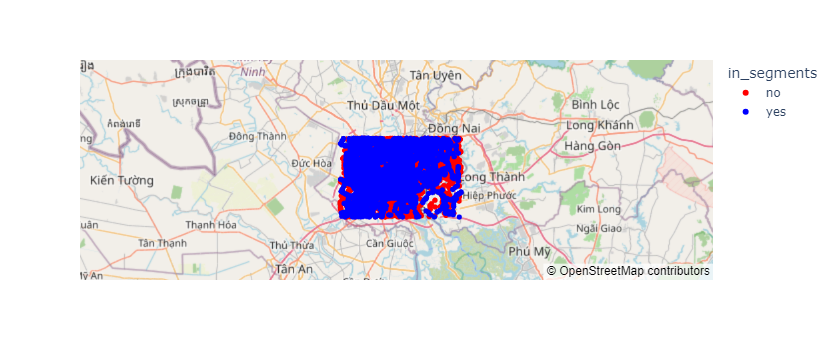

In [9]:
fig = px.scatter_map(
    sample_df,
    lat="lat",
    lon="long",
    color="in_segments",
    color_discrete_map={
        "yes": "blue",
        "no": "red"
    }
)

fig.update_layout(map_style="open-street-map")
fig.show()

In [10]:
nodes_df["long"].mean(), nodes_df["lat"].mean()

(np.float64(106.7036998547995), np.float64(10.808332114769009))

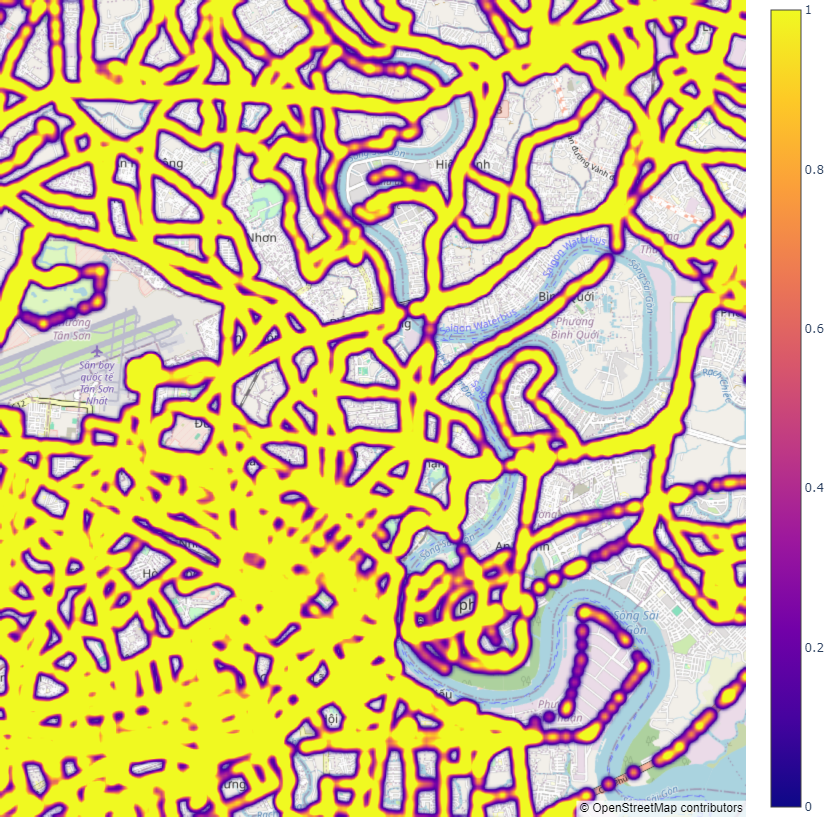

In [11]:
import plotly.graph_objects as go

fig = go.Figure(go.Densitymap(lat=isin_segments_df.lat, lon=isin_segments_df.long,
                                 radius=10))
fig.update_layout(
    map_style="open-street-map",
    map_center={
        "lat": nodes_df.lat.mean(),
        "lon": nodes_df.long.mean(),
    },
    map_zoom=12
)
fig.update_layout(
    margin={"r":0,"t":0,"l":0,"b":0},
    width=1200,
    height=800
)
fig.show()

# Xem các segment trên đường nhiều record nhất

In [12]:
min_record = -1

filtered_segments_df = segments_df[["street_name", "type", "s_node_id", "e_node_id"]]
street_counts = filtered_segments_df.groupby("street_name").size()
max_street = street_counts.idxmax()
max_count = street_counts.max()

print(max_street, max_count)

Quốc lộ 1 2142


In [13]:
max_street_df = filtered_segments_df[filtered_segments_df["street_name"] == max_street]
s_nodes_df = nodes_df.copy().rename(columns={
    "_id": "s_node_id",
    "long": "long_snode",
    "lat": "lat_snode"
})
e_nodes_df = nodes_df.copy().rename(columns={
    "_id": "e_node_id",
    "long": "long_enode",
    "lat": "lat_enode"
})

In [14]:
max_street_nodes_df = max_street_df.merge(
    s_nodes_df,
    on="s_node_id",
    how="inner"
)
max_street_nodes_df = max_street_nodes_df.merge(
    e_nodes_df,
    on="e_node_id",
    how="inner"
)
max_street_nodes_df.head()

,street_name,type,s_node_id,e_node_id,long_snode,lat_snode,long_enode,lat_enode
0,Quốc lộ 1,trunk_link,366443014,5772493649,106.747454,10.874119,106.747630,10.874120
1,Quốc lộ 1,trunk_link,5772493649,1958801756,106.747630,10.874120,106.747722,10.874126
2,Quốc lộ 1,trunk_link,1958801756,366441405,106.747722,10.874126,106.747985,10.874094
3,Quốc lộ 1,trunk_link,366441405,366458482,106.747985,10.874094,106.748233,10.874043
4,Quốc lộ 1,trunk_link,366458482,1958801734,106.748233,10.874043,106.748443,10.874000


In [15]:
max_street_nodes_df.to_csv("../data/preprocess/max_street_nodes_df.csv", index=False)

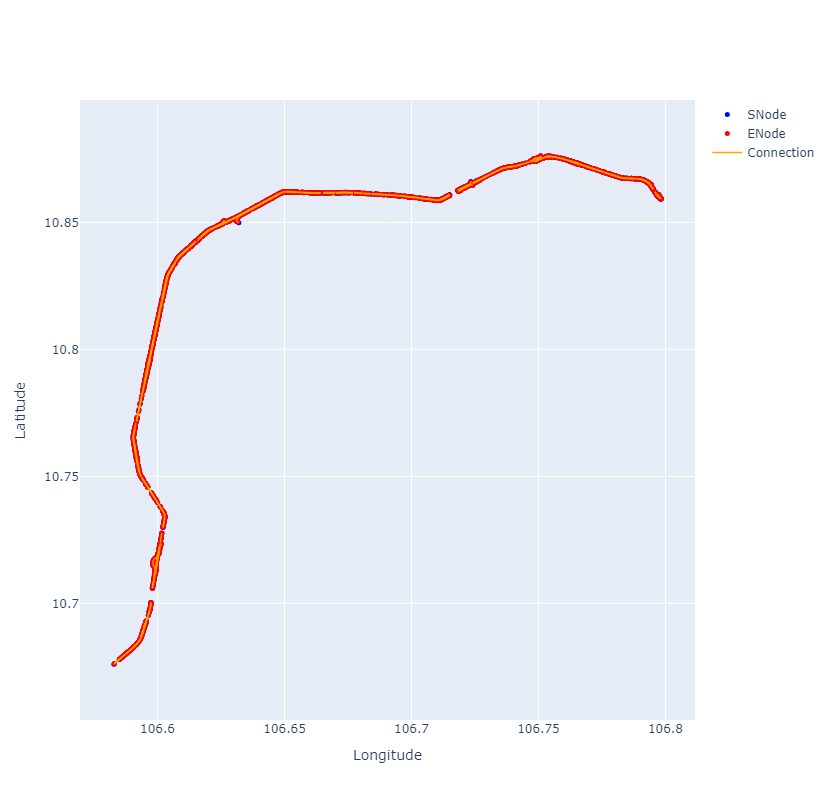

In [16]:
fig = go.Figure()

# SNode
fig.add_trace(go.Scatter(
    x=max_street_nodes_df["long_snode"],
    y=max_street_nodes_df["lat_snode"],
    mode="markers",
    marker=dict(size=5, color="blue"),
    name="SNode"
))

# ENode
fig.add_trace(go.Scatter(
    x=max_street_nodes_df["long_enode"],
    y=max_street_nodes_df["lat_enode"],
    mode="markers",
    marker=dict(size=5, color="red"),
    name="ENode"
))

# Lines
xs = []
ys = []

for _, row in max_street_nodes_df.iterrows():
    xs.extend([row["long_snode"], row["long_enode"], None])
    ys.extend([row["lat_snode"], row["lat_enode"], None])

fig.add_trace(go.Scatter(
    x=xs,
    y=ys,
    mode="lines",
    line=dict(width=1.5, color="orange"),
    name="Connection"
))

# Quan trọng: giữ tỷ lệ đúng như bản đồ
fig.update_layout(
    height=800,
    xaxis_title="Longitude",
    yaxis_title="Latitude",
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

# Xem segments của đường đô thị cấp 1

In [17]:
primary_segments_df = filtered_segments_df[filtered_segments_df["type"] == "primary"]
primary_street_counts = primary_segments_df.groupby("street_name").size()
max__primary_street = primary_street_counts.idxmax()
max_primary_count = primary_street_counts.max()

print(max__primary_street, max_primary_count)

Võ Văn Kiệt 440


In [18]:
max_primary_street_df = filtered_segments_df[filtered_segments_df["street_name"] == max_street].copy()
max_primary_street_nodes_df = max_primary_street_df.merge(
    s_nodes_df,
    on="s_node_id",
    how="inner"
)
max_primary_street_nodes_df = max_primary_street_nodes_df.merge(
    e_nodes_df,
    on="e_node_id",
    how="inner"
)
max_primary_street_nodes_df.head()

,street_name,type,s_node_id,e_node_id,long_snode,lat_snode,long_enode,lat_enode
0,Quốc lộ 1,trunk_link,366443014,5772493649,106.747454,10.874119,106.747630,10.874120
1,Quốc lộ 1,trunk_link,5772493649,1958801756,106.747630,10.874120,106.747722,10.874126
2,Quốc lộ 1,trunk_link,1958801756,366441405,106.747722,10.874126,106.747985,10.874094
3,Quốc lộ 1,trunk_link,366441405,366458482,106.747985,10.874094,106.748233,10.874043
4,Quốc lộ 1,trunk_link,366458482,1958801734,106.748233,10.874043,106.748443,10.874000


In [19]:
max_primary_street_nodes_df.to_csv("../data/preprocess/max_primary_street_nodes.csv", index=False)

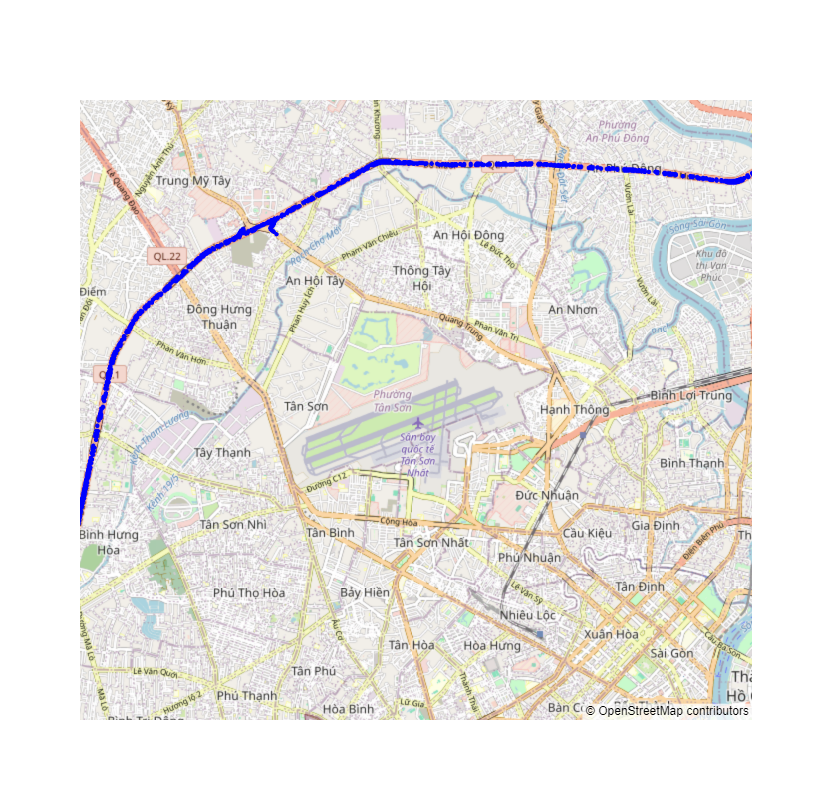

In [20]:
all_lon = np.concatenate([
    max_primary_street_nodes_df["long_snode"],
    max_primary_street_nodes_df["long_enode"]
])

all_lat = np.concatenate([
    max_primary_street_nodes_df["lat_snode"],
    max_primary_street_nodes_df["lat_enode"]
])

fig = go.Figure()

fig.add_trace(go.Scattermap(
    lat=all_lat,
    lon=all_lon,
    mode="markers",
    marker=dict(size=5, color="blue")
))

fig.update_layout(
    map_style="open-street-map",
    map=dict(
        center=dict(lat=all_lat.mean(), lon=all_lon.mean()),
        zoom=12,
    ),
    height=800
)

fig.show()

# Xem segment đường khác type

In [21]:
import numpy as np

# 1. Đếm số lượng (street_name, type)
type_counts = (
    filtered_segments_df
    .groupby(["street_name", "type"])
    .size()
    .reset_index(name="count")
)

# 2. Pivot thành ma trận (street x type)
pivot_df = type_counts.pivot(
    index="street_name",
    columns="type",
    values="count"
).fillna(0)

# 3. Hàm entropy
def entropy(row):
    total = row.sum()
    if total == 0:
        return 0
    p = row / total
    p = p[p > 0]
    return -(p * np.log2(p)).sum()

# 4. Tính entropy cho từng street
pivot_df["entropy"] = pivot_df.apply(entropy, axis=1)

# 5. Lấy street mâu thuẫn nhất
most_conflict_street = pivot_df.sort_values("entropy", ascending=False).head(1)

most_conflict_street

type,apartments,atm,bank,bridge,bus_station,bus_stop,car,chalet,church,cinema,...,tertiary,tertiary_link,theme_park,training_area,trunk,trunk_link,unclassified,university,yes,entropy
street_name,,,,,,,,,,,,,,,,,,,,,
Đường Kinh Dương Vương,0.0,5.0,11.0,0.0,7.0,13.0,3.0,0.0,1.0,0.0,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,3.364917


In [22]:
most_conflict_street_df = filtered_segments_df[filtered_segments_df["street_name"] == "Đường Kinh Dương Vương"].copy()
most_conflict_street_nodes_df = most_conflict_street_df.merge(
    s_nodes_df,
    on="s_node_id",
    how="inner",
)
most_conflict_street_nodes_df = most_conflict_street_nodes_df.merge(
    e_nodes_df,
    on="e_node_id",
    how="inner",
)
most_conflict_street_nodes_df.head()

,street_name,type,s_node_id,e_node_id,long_snode,lat_snode,long_enode,lat_enode
0,Đường Kinh Dương Vương,primary_link,4984435433,4984435434,106.634016,10.753634,106.634112,10.753598
1,Đường Kinh Dương Vương,primary_link,4984435434,4984435435,106.634112,10.753598,106.634175,10.753585
2,Đường Kinh Dương Vương,primary_link,4984435435,4984435436,106.634175,10.753585,106.634244,10.753563
3,Đường Kinh Dương Vương,fuel,5797841733,5797843768,106.614209,10.736471,106.614270,10.736588
4,Đường Kinh Dương Vương,fuel,5797843768,5797843767,106.614270,10.736588,106.614482,10.736936


In [23]:
most_conflict_street_nodes_df.to_csv("../data/preprocess/most_conflict_street_nodes_df.csv",index=False)

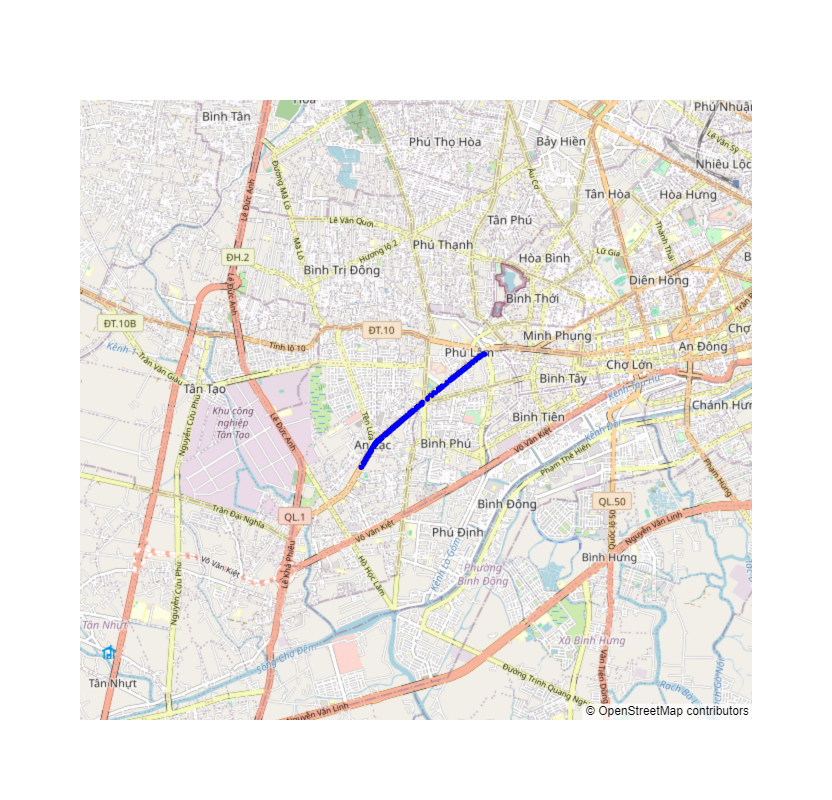

In [24]:
all_lon = np.concatenate([
    most_conflict_street_nodes_df["long_snode"],
    most_conflict_street_nodes_df["long_enode"]
])

all_lat = np.concatenate([
    most_conflict_street_nodes_df["lat_snode"],
    most_conflict_street_nodes_df["lat_enode"]
])

fig = go.Figure()

fig.add_trace(go.Scattermap(
    lat=all_lat,
    lon=all_lon,
    mode="markers",
    marker=dict(size=5, color="blue")
))

fig.update_layout(
    map_style="open-street-map",
    map=dict(
        center=dict(lat=all_lat.mean(), lon=all_lon.mean()),
        zoom=12,
    ),
    height=800
)

fig.show()

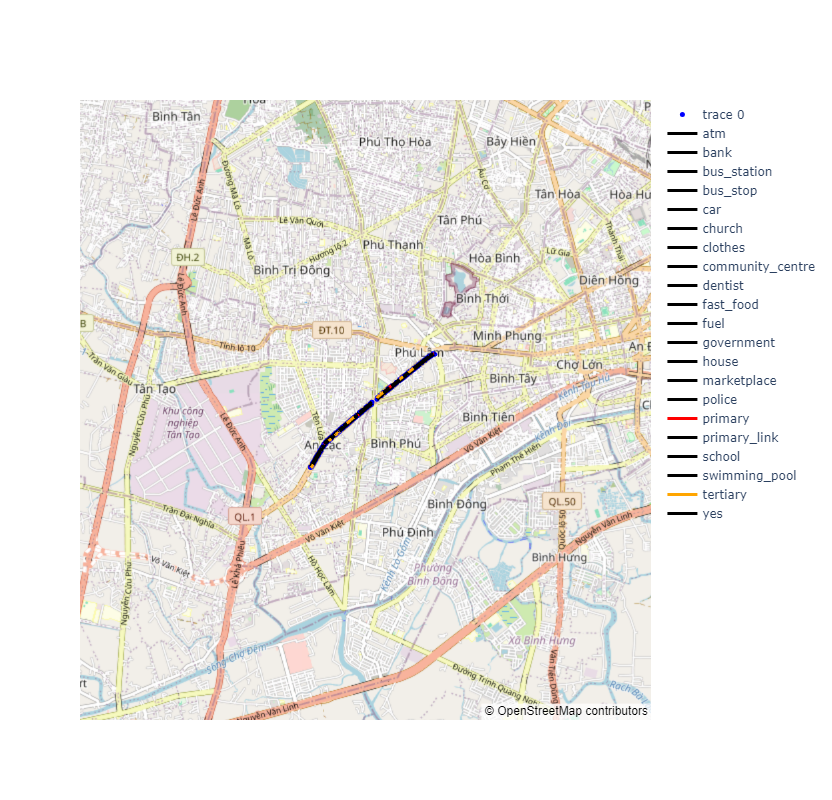

In [25]:
import plotly.graph_objects as go

fig = go.Figure()

# --- Nodes (KHÔNG có label) ---
fig.add_trace(go.Scattermap(
    lat=all_lat,
    lon=all_lon,
    mode="markers",
    marker=dict(size=5, color="blue"),
))

# --- Mapping màu ---
color_map = {
    "primary": "red",
    "secondary": "green",
    "tertiary": "orange"
}

# --- Lines (CÓ label) ---
for t, group in most_conflict_street_nodes_df.groupby("type"):
    lat_lines = []
    lon_lines = []

    for _, row in group.iterrows():
        lat_lines += [row["lat_snode"], row["lat_enode"], None]
        lon_lines += [row["long_snode"], row["long_enode"], None]

    fig.add_trace(go.Scattermap(
        lat=lat_lines,
        lon=lon_lines,
        mode="lines",
        line=dict(width=3, color=color_map.get(t, "black")),
        name=f"{t}"
    ))

# --- Layout ---
fig.update_layout(
    map_style="open-street-map",
    map=dict(
        center=dict(lat=all_lat.mean(), lon=all_lon.mean()),
        zoom=12,
    ),
    height=800
)

fig.show()

# Mối quan hệ giữa các thuộc tính và tốc độ

In [48]:
filtered_all_df = all_df[["segment_id", "period", "street_level", "velocity", "segment_type", "street_type", "length", "LOS"]]

In [49]:
# Ordinal Encoding cho LOS, ['A', 'F'] -> [0, 5], F phục vụ nhiều nhất
filtered_all_df["LOS"] = filtered_all_df["LOS"].map(lambda x: ord(x) - ord('A'))

# Ordinal Encoding street level, [1, 4] -> [0, 3], cấp giao thông 1 cao nhất
filtered_all_df["street_level"] = 4 - filtered_all_df["street_level"] 

C:\Users\Asriel\AppData\Local\Temp\ipykernel_10444\1068655024.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Asriel\AppData\Local\Temp\ipykernel_10444\1068655024.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [51]:
oh_all_df = pd.get_dummies(filtered_all_df, columns=["segment_type", "street_type"])
oh_feat_segment_type = [x for x in oh_all_df.columns if x.startswith("segment_type_")]
oh_feat_street_type = [x for x in oh_all_df.columns if x.startswith("street_type_")]
oh_feat_list = oh_feat_segment_type + oh_feat_street_type

not_oh_feat_list = ["street_level", "length", "LOS"]
feat_list = not_oh_feat_list + oh_feat_list

In [53]:
X = oh_all_df[feat_list].values.astype(float)
y = oh_all_df["velocity"]

In [54]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [55]:
y_pred = model.predict(X)
rmse = np.sqrt(y, y_pred)
print(rmse.mean())

3.9293942188209403


In [56]:
model.coef_

array([  1.78373774,   5.83360078,  -9.08346667,   0.47970428,
         7.71664082,   2.03288099,  -3.39958636,  -5.48305303,
         2.63826963,  -2.49292397,  -6.26951303,   6.2740787 ,
        -0.0246342 ,  -2.81690585,   4.66055207,   6.49199472,
        -9.18891872,   3.02816934,  -0.46366782,   4.53667591,
         0.54150477,   0.25899273,  -0.70169149,   1.86240171,
         0.33109866,  -1.5648932 ,  -0.30990729,   2.52662525,
       -10.66389465,   4.66055207,   6.49199472,  -6.38947987,
        -0.46366782,   0.25899273,  -0.70169149,  -0.54468327,
         0.33109866,  -1.5648932 ,  -0.30990729,  -1.76831526])

In [57]:
vertical_sum = oh_all_df[feat_list].sum(axis=0)
vertical_sum.loc[not_oh_feat_list] = len(all_df)
vertical_sum

street_level                   90938.0
length                         90938.0
LOS                            90938.0
segment_type_bank                  1.0
segment_type_bus_station           1.0
segment_type_car                  12.0
segment_type_cinema                1.0
segment_type_clothes               1.0
segment_type_company              20.0
segment_type_convenience           1.0
segment_type_fuel                  4.0
segment_type_government            2.0
segment_type_house                76.0
segment_type_marketplace          10.0
segment_type_motorway            119.0
segment_type_motorway_link        15.0
segment_type_pitch                 1.0
segment_type_primary           27725.0
segment_type_primary_link        883.0
segment_type_residential         203.0
segment_type_school               20.0
segment_type_secondary          8025.0
segment_type_secondary_link      397.0
segment_type_tertiary          45015.0
segment_type_tertiary_link       227.0
segment_type_trunk       

In [58]:
feat_importance = pd.Series(model.coef_, index=feat_list)
feat_importance.sort_values()

segment_type_university       -10.663895
segment_type_pitch             -9.188919
LOS                            -9.083467
street_type_primary            -6.389480
segment_type_fuel              -6.269513
segment_type_clothes           -5.483053
segment_type_cinema            -3.399586
segment_type_marketplace       -2.816906
segment_type_convenience       -2.492924
street_type_unclassified       -1.768315
street_type_trunk              -1.564893
segment_type_trunk             -1.564893
segment_type_secondary_link    -0.701691
street_type_secondary_link     -0.701691
street_type_tertiary           -0.544683
street_type_primary_link       -0.463668
segment_type_primary_link      -0.463668
street_type_trunk_link         -0.309907
segment_type_trunk_link        -0.309907
segment_type_house             -0.024634
segment_type_secondary          0.258993
street_type_secondary           0.258993
segment_type_tertiary_link      0.331099
street_type_tertiary_link       0.331099
segment_type_ban

In [59]:
df_info = pd.concat({
    'Count': vertical_sum, 
    'Importance': feat_importance.abs(),
    "Sign": feat_importance.map(lambda x: '-' if x < 0 else '+')
}, axis=1)

In [65]:
df_oh_info = df_info.drop(index=not_oh_feat_list)
df_oh_info['h_score_weighted'] = (
    (df_info['Importance'] * df_info['Count']) /  \
    (2*df_info['Importance'] + df_info['Count'])
)
df_oh_info.sort_values(["h_score_weighted", "Count", "Importance"], ascending=False)

,Count,Importance,Sign,h_score_weighted
street_type_primary,27723.0,6.389480,-,6.386536
segment_type_residential,203.0,4.536676,+,4.342579
street_type_motorway,119.0,4.660552,+,4.322015
segment_type_motorway,119.0,4.660552,+,4.322015
segment_type_motorway_link,15.0,6.491995,+,3.479844
street_type_motorway_link,15.0,6.491995,+,3.479844
segment_type_primary,27725.0,3.028169,+,3.027508
segment_type_unclassified,5135.0,2.526625,+,2.524141
segment_type_company,20.0,2.638270,+,2.087524
segment_type_tertiary,45015.0,1.862402,+,1.862248


In [72]:
threshold = df_oh_info['h_score_weighted'].quantile(0.75)   
important_segments_df = df_oh_info[df_oh_info['h_score_weighted'] >= threshold]
important_segments_df.sort_values(["h_score_weighted", "Count", "Importance"], ascending=False)

,Count,Importance,Sign,h_score_weighted
street_type_primary,27723.0,6.389480,-,6.386536
segment_type_residential,203.0,4.536676,+,4.342579
street_type_motorway,119.0,4.660552,+,4.322015
segment_type_motorway,119.0,4.660552,+,4.322015
segment_type_motorway_link,15.0,6.491995,+,3.479844
street_type_motorway_link,15.0,6.491995,+,3.479844
segment_type_primary,27725.0,3.028169,+,3.027508
segment_type_unclassified,5135.0,2.526625,+,2.524141
segment_type_company,20.0,2.638270,+,2.087524
segment_type_tertiary,45015.0,1.862402,+,1.862248


In [69]:
important_segments_feats = important_segments_df.index.to_list()
important_segments_feats

['segment_type_company',
 'segment_type_motorway',
 'segment_type_motorway_link',
 'segment_type_primary',
 'segment_type_residential',
 'segment_type_tertiary',
 'segment_type_unclassified',
 'street_type_motorway',
 'street_type_motorway_link',
 'street_type_primary']